# 04 — Experimento 1: TF-IDF + Regresión Logística

Primer experimento de modelado: baseline léxico. Representamos cada minuta con TF-IDF
(unigramas + bigramas) y entrenamos una regresión logística multinomial. Es el piso de
rendimiento que los modelos más complejos (lexicón, Word2Vec, FinBERT) deben superar.

**Input:** `data/processed/fomc_dataset.csv`

**Outputs:** figuras en `reports/figures/` (`04_confusion_val.png`, `04_confusion_test.png`)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.max_colwidth = 200

# Rutas (mismas convenciones que notebooks 02/03)
BASE_DIR       = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS_DIR    = BASE_DIR / 'reports' / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['hike', 'cut', 'hold']

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

# Cargar dataset y particiones cronológicas (ya materializadas en la columna 'split')
df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset.csv', parse_dates=['date'])
train = df[df.split == 'train']
val   = df[df.split == 'val']
test  = df[df.split == 'test']

print('train:', len(train), '| val:', len(val), '| test:', len(test))
print(pd.crosstab(df['label'], df['split']))

train: 153 | val: 16 | test: 24
split  test  train  val
label                  
cut       0     18    5
hike     11     27    1
hold     13    108   10


## Nota sobre la clase `cut` en test

El split cronológico (test = 2021–2023) **no contiene ningún documento de clase `cut`**: en
ese período la Fed no recortó la tasa. Por eso:

- La **selección de modelo y la comparación entre experimentos se hace sobre validación**
  (2019–2020), que sí contiene las tres clases y permite un F1-macro comparable.
- El **test se reporta como generalización out-of-sample**. En su `classification_report`,
  `cut` aparece con `support = 0` (no es evaluable), y el F1-macro de test queda calculado
  efectivamente sobre dos clases (`hike`, `hold`). No es directamente comparable con el F1-macro
  de validación (tres clases).

Esta limitación se documenta también en la sección "Limitaciones" de la presentación final.

In [2]:
# Helper de evaluación compartido por todos los experimentos.
# Reporta accuracy + F1-macro + classification_report (P/R/F1 por clase) + matriz de confusión.
#
# IMPORTANTE: el F1-macro se promedia SOLO sobre las clases efectivamente presentes en y_true
# y se imprime cuántas son. En val están las 3 clases; en test falta `cut` (support=0), así que
# el F1-macro de test se promedia sobre 2 clases y NO es directamente comparable con el de val.
def evaluar(y_true, y_pred, titulo, fname=None):
    clases_presentes = [c for c in LABEL_ORDER if c in set(y_true)]
    f1 = f1_score(y_true, y_pred, labels=clases_presentes, average='macro')

    print(titulo)
    print('accuracy :', round(accuracy_score(y_true, y_pred), 4))
    print(f'f1_macro : {round(f1, 4)}  (promedio sobre {len(clases_presentes)} clases presentes: {clases_presentes})')
    print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo)
    if fname:
        save_fig(fname)
    plt.show()
    return f1

## 1. Baseline trivial (clase mayoritaria)

`DummyClassifier(strategy='prior')` predice siempre la clase mayoritaria de train (`hold`).
Es la cota inferior: cualquier modelo útil debe superar su F1-macro.

Baseline (majority) — VAL
accuracy : 0.625
f1_macro : 0.2564  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00         1
         cut       0.00      0.00      0.00         5
        hold       0.62      1.00      0.77        10

    accuracy                           0.62        16
   macro avg       0.21      0.33      0.26        16
weighted avg       0.39      0.62      0.48        16



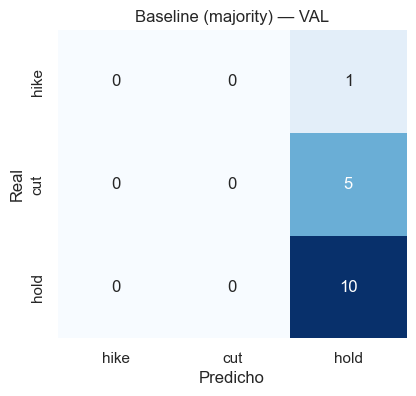

Baseline (majority) — TEST
accuracy : 0.5417
f1_macro : 0.3514  (promedio sobre 2 clases presentes: ['hike', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         0
        hold       0.54      1.00      0.70        13

    accuracy                           0.54        24
   macro avg       0.18      0.33      0.23        24
weighted avg       0.29      0.54      0.38        24



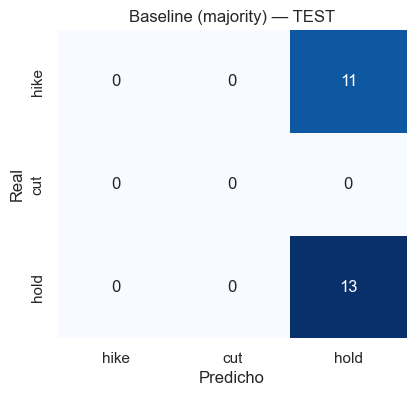

0.35135135135135137

In [3]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(train['text'], train['label'])

evaluar(val['label'],  dummy.predict(val['text']),  'Baseline (majority) — VAL')
evaluar(test['label'], dummy.predict(test['text']), 'Baseline (majority) — TEST')

## 2. TF-IDF + Regresión Logística

Vectorizador ajustado **solo sobre train** (evita data leakage). Configuración del spec:
`ngram_range=(1,2)`, `max_features=10000`, `sublinear_tf=True`. La regresión logística usa
`class_weight='balanced'` por el desbalance de clases, y tuneamos `C` sobre validación.

In [4]:
# Ajustar TF-IDF solo en train; transformar las tres particiones
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_train = vectorizer.fit_transform(train['text'])
X_val   = vectorizer.transform(val['text'])
X_test  = vectorizer.transform(test['text'])
y_train, y_val, y_test = train['label'], val['label'], test['label']

print('Vocabulario TF-IDF:', len(vectorizer.vocabulary_))
print('X_train:', X_train.shape)

Vocabulario TF-IDF: 10000
X_train: (153, 10000)


In [5]:
# Grid search de C sobre validación (F1-macro)
C_grid = [0.01, 0.1, 1, 10]
resultados = []
for C in C_grid:
    clf = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
    clf.fit(X_train, y_train)
    f1_val = f1_score(y_val, clf.predict(X_val), average='macro')
    resultados.append((C, f1_val))
    print(f'C={C:<5} -> F1-macro val = {f1_val:.4f}')

best_C = max(resultados, key=lambda t: t[1])[0]
print(f'\nMejor C (por F1-macro en val): {best_C}')

C=0.01  -> F1-macro val = 0.2564
C=0.1   -> F1-macro val = 0.2564
C=1     -> F1-macro val = 0.2564
C=10    -> F1-macro val = 0.2564

Mejor C (por F1-macro en val): 0.01


TF-IDF + LogReg (C=0.01) — VAL
accuracy : 0.625
f1_macro : 0.2564  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00         1
         cut       0.00      0.00      0.00         5
        hold       0.62      1.00      0.77        10

    accuracy                           0.62        16
   macro avg       0.21      0.33      0.26        16
weighted avg       0.39      0.62      0.48        16



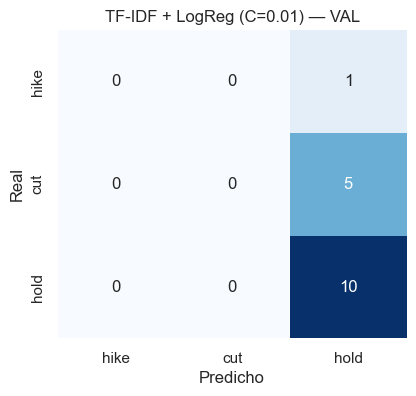

TF-IDF + LogReg (C=0.01) — TEST
accuracy : 0.5417
f1_macro : 0.3514  (promedio sobre 2 clases presentes: ['hike', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         0
        hold       0.54      1.00      0.70        13

    accuracy                           0.54        24
   macro avg       0.18      0.33      0.23        24
weighted avg       0.29      0.54      0.38        24



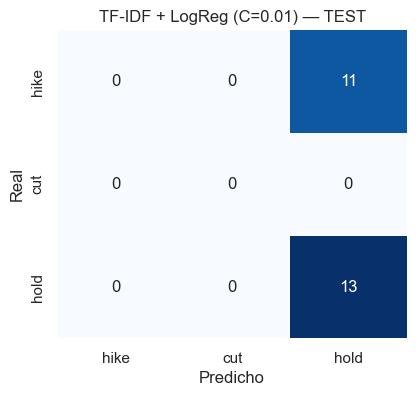

0.35135135135135137

In [6]:
# Reentrenar con el mejor C y evaluar en val y test
clf = LogisticRegression(C=best_C, max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

evaluar(y_val,  clf.predict(X_val),  f'TF-IDF + LogReg (C={best_C}) — VAL',  '04_confusion_val.png')
evaluar(y_test, clf.predict(X_test), f'TF-IDF + LogReg (C={best_C}) — TEST', '04_confusion_test.png')

## 3. Features más discriminativos por clase

Los coeficientes de la regresión logística (uno por clase, OvR multinomial) indican qué
n-gramas empujan cada decisión. Útil para interpretar y para la presentación.

In [7]:
feature_names = np.array(vectorizer.get_feature_names_out())
top_n = 15
for i, clase in enumerate(clf.classes_):
    top_idx = np.argsort(clf.coef_[i])[::-1][:top_n]
    print(f'\n[{clase}] top {top_n} features:')
    print(', '.join(feature_names[top_idx]))


[cut] top 15 features:
economic weakness, easing, point reduction, basis point, consistent reducing, reducing funds, weakness foreseeable, meyer minehan, policy easing, easing action, attacks, hoenig kelley, terrorist attacks, easing policy, generate economic

[hike] top 15 features:
prospects needed, respond changes, likely measured, removed pace, removed, maintain price, fulfill, risks attainment, attainment sustainable, needed fulfill, fulfill obligation, obligation maintain, growth price, changes economic, pace likely

[hold] top 15 features:
mbs, economic recovery, william, remained stable, mortgagebacked, mortgagebacked securities, agency mortgagebacked, mandate, david, range funds, maximum employment, target range, tarullo, longerrun, desk


## 4. Interpretación

- **El modelo predice `hold` a TODOS los documentos, tanto en validación como en test**, para
  cualquier valor de `C`. Colapsa a la clase mayoritaria: no detecta ni un solo `hike` ni `cut`.
  Iguala exactamente al baseline trivial. Con 153 documentos de entrenamiento y 10 000 features,
  y con el drift de vocabulario entre train (2000–2018) y los períodos de evaluación, el TF-IDF
  no logra separar las clases minoritarias.
- **Cuidado con el número de test (F1-macro ≈ 0.35 vs ≈ 0.26 en val):** NO significa que el
  modelo ande mejor en test. Predice `hold` a todo en ambos. El test parece más alto solo porque
  el F1-macro allí se promedia sobre 2 clases (`hike`, `hold`; no hay `cut`) en vez de 3. Por eso
  los F1-macro de val y test no son comparables, y **la comparación entre experimentos se hace
  sobre validación** (3 clases).
- **Los coeficientes sí son interpretables y coherentes con el dominio**: aunque el modelo no
  generalice, sus pesos asocian `cut` a vocabulario *dovish* (`easing`, `point reduction`,
  `basis point`, `policy easing`), `hike` a lenguaje de endurecimiento (`measured pace`,
  `removed`, `maintain price`) y `hold` a términos de la era de QE (`target range`, `mbs`,
  `maximum employment`). Hay señal léxica, pero insuficiente para clasificar fuera de train.

**Conclusión del experimento:** TF-IDF + LogReg es un baseline débil que no supera al
clasificador trivial: predice siempre `hold`. Esto motiva representaciones que capturen tono de
dominio (lexicón Loughran-McDonald, Exp 2) y semántica/contexto (Word2Vec y FinBERT, Exp 3 y 4).